In [1]:
from qecdec.experiments import HexColorCode_Phenom_Memory
import drawsvg as draw

In [2]:
expmt = HexColorCode_Phenom_Memory(
    d=11, rounds=11, basis="X", data_qubit_error_rate=0.01, meas_error_rate=0.01
)

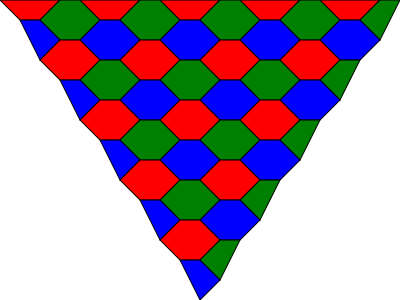

In [3]:
from qecdec.experiments.hex_color_code_phenom_mem import _Tile


def draw_tiles(tiles: list[_Tile], scaling: float = 20):
    width = max(v.real for t in tiles for v in t.vertices) * scaling
    height = max(v.imag for t in tiles for v in t.vertices) * scaling

    d = draw.Drawing(width, height)

    colors = ["red", "green", "blue"]

    for t in tiles:
        p = draw.Path(fill=colors[t.color], stroke="black")
        p.M(t.vertices[0].real * scaling, t.vertices[0].imag * scaling)
        for v in t.vertices[1:]:
            p.L(v.real * scaling, v.imag * scaling)
        p.Z()
        d.append(p)

    return d


draw_tiles(expmt.tiles)